In [1]:
#from langchain_openai import ChatOpenAI

# 모델 초기화
#model = ChatOpenAI(model="gpt-4o", temperature=0.01)
#model.invoke('안녕하세요!')

from langchain_ollama import ChatOllama

model = ChatOllama(model="gemma4:e2b", base_url="http://127.0.0.1:11434") 
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 저는 Google에서 훈련한 대규모 언어 모델입니다.\n\n무엇을 도와드릴까요? 😊', additional_kwargs={}, response_metadata={'model': 'gemma4:e2b', 'created_at': '2026-08-22T06:37:04.3426749Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6128437100, 'load_duration': 5801815800, 'prompt_eval_count': 18, 'prompt_eval_duration': 93910000, 'eval_count': 25, 'eval_duration': 229629000, 'logprobs': None, 'model_name': 'gemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--01a0282f-d3e3-7690-bbed-03dd47ccb2f1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 25, 'total_tokens': 43})

In [2]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다. 
        주석에 있는 'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State) 

In [4]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

import bs4
from langchain_community.document_loaders import WebBaseLoader

# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재시각 {now}'
        # print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"
    
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region="kr-kr", 
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_current_time, get_web_search]

C:\Users\artsr\AppData\Local\Temp\ipykernel_22816\3084828456.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchResults
E:\Project\AI-course\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [5]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "서울"})

'Asia/Seoul (서울) 현재시각 2026-08-22 15:44:37'

In [7]:
tools[1].invoke({"query": "파이썬", "search_period": "m"})


-------- WEB SEARCH --------
파이썬
m
1. snippet: 6 days ago · AI에게 코드를 짜 달라고 하면 대체로 그럴듯한 답이 돌아온다. 문제는 그다음이다. "이 코드가 맞는지 나는 어떻게 아는가?"LLM은 정답을 찾아오는 검색기가 아니라 다음에 올 단어를 확률로 고르는 모델이다. 그래서 존재하지 않는 메서드를 부르고, 반환값을 착각하고, 파이썬 딕셔너리를 자바 ..., title: 파이썬 기초 (1) - 핵심문법 — It것저것, link: https://it-study-2002.tistory.com/entry/파이썬-기초1-핵심문법
2. snippet: Aug 7, 2026 · 직전 글에서 숫자와 문자열의 자료형을 구분했다면, 이제 그 값에 이름을 붙여 코드 안에서 다시 사용하는 차례입니다. 자료형부터 보고 싶다면 파이썬 자료형 기초 를 먼저 읽어도 좋습니다., title: 파이썬 변수 기초 : 값에 이름을 붙이면 무엇이 편해질까, link: https://manniz.tistory.com/entry/python-variables-basics
3. snippet: Jul 28, 2026 · 위에서 소개한 내용을 종합해보면 결국 파이썬 매개변수는 아래와 같은 순서에 따라 입력을 받아야 한다. 미리 정의된 매개변수 이름과 개수가 정의되어 있지 않은 매개변수 (*args) – 리스트, 튜플 미리 정의된 키워드 매개변수 – 딕셔너리, title: 파이썬 함수 이해하기 (parameter, keyword arguments 다루기) | 아무..., link: https://hleecaster.github.io/posts/python_function_arguments/
4. snippet: Jul 26, 2026 · 파이썬 2와 3에서의 range 는 리턴 형식이 다르다. 2에서는 리스트를 리턴하지만 3에서는 range 객체를 리턴한다. 따라서 3에서 range 를 리스트로 바꾸려면 아래와 같은 방법들로 전환해야 한다., title: 

'snippet: 6 days ago · AI에게 코드를 짜 달라고 하면 대체로 그럴듯한 답이 돌아온다. 문제는 그다음이다. "이 코드가 맞는지 나는 어떻게 아는가?"LLM은 정답을 찾아오는 검색기가 아니라 다음에 올 단어를 확률로 고르는 모델이다. 그래서 존재하지 않는 메서드를 부르고, 반환값을 착각하고, 파이썬 딕셔너리를 자바 ..., title: 파이썬 기초 (1) - 핵심문법 — It것저것, link: https://it-study-2002.tistory.com/entry/파이썬-기초1-핵심문법;\nsnippet: Aug 7, 2026 · 직전 글에서 숫자와 문자열의 자료형을 구분했다면, 이제 그 값에 이름을 붙여 코드 안에서 다시 사용하는 차례입니다. 자료형부터 보고 싶다면 파이썬 자료형 기초 를 먼저 읽어도 좋습니다., title: 파이썬 변수 기초 : 값에 이름을 붙이면 무엇이 편해질까, link: https://manniz.tistory.com/entry/python-variables-basics;\nsnippet: Jul 28, 2026 · 위에서 소개한 내용을 종합해보면 결국 파이썬 매개변수는 아래와 같은 순서에 따라 입력을 받아야 한다. 미리 정의된 매개변수 이름과 개수가 정의되어 있지 않은 매개변수 (*args) – 리스트, 튜플 미리 정의된 키워드 매개변수 – 딕셔너리, title: 파이썬 함수 이해하기 (parameter, keyword arguments 다루기) | 아무..., link: https://hleecaster.github.io/posts/python_function_arguments/;\nsnippet: Jul 26, 2026 · 파이썬 2와 3에서의 range 는 리턴 형식이 다르다. 2에서는 리스트를 리턴하지만 3에서는 range 객체를 리턴한다. 따라서 3에서 range 를 리스트로 바꾸려면 아래와 같은 방법들로 전환해야 한다., title: Python/문법 - 나무위키, link: https://namu.wiki

In [8]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x00000211AE2239C0>
get_web_search name='get_web_search' description='웹 검색을 수행하는 함수.\n\nArgs:\n    query (str): 검색어\n    search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)\n\nReturns:\n    str: 검색 결과' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x00000211AE442520>


In [9]:
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결

def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.

    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [10]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    Attributes:
        tools_by_name (dict): 도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전입니다.
    Methods:
        __init__(tools: list): 도구 객체들의 리스트를 받아서 초기화합니다.
        __call__(inputs: dict): 입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환합니다.
    """
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:    # ①
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):    # ②
        if messages := inputs.get("messages", []):
            # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트를 가져옵니다.
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:    # ③
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [11]:
def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 끝으로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "generate")
graph = graph_builder.compile()


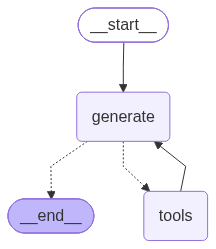

In [12]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [13]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 서울 몇시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

gathered

현재 서울은 2026년 8월 22일 15시 46분 39초입니다.

AIMessageChunk(content='현재 서울은 2026년 8월 22일 15시 46분 39초입니다.', additional_kwargs={}, response_metadata={'model': 'gemma4:e2bgemma4:e2b', 'created_at': '2026-08-22T06:46:39.15536Z2026-08-22T06:46:40.2182154Z', 'done': True, 'done_reason': 'stopstop', 'total_duration': 9561793700, 'load_duration': 5798575600, 'prompt_eval_count': 490, 'prompt_eval_duration': 149491000, 'eval_count': 422, 'eval_duration': 3598727000, 'logprobs': None, 'model_name': 'gemma4:e2bgemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--01a02838-8ffa-76f3-bc45-889573395068', tool_calls=[{'name': 'get_current_time', 'args': {'location': 'Seoul', 'timezone': 'Asia/Seoul'}, 'id': '21d5e43a-51ad-4210-a3f6-e19abab7c1a0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 490, 'output_tokens': 422, 'total_tokens': 912}, tool_call_chunks=[{'name': 'get_current_time', 'args': '{"location": "Seoul", "timezone": "Asia/Seoul"}', 'id': '21d5e43a-51ad-4210-a3f6-e19abab7c1a0', 'index': None, 'type': '

In [14]:
from langchain_core.messages import AIMessageChunk, SystemMessage

about = "서울월드컵 경기장 잔디 문제"

inputs = [SystemMessage(content=f"""
너는 신문기자이다. 
최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.  

- 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘. 
- 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐. 
- 검색할 리스트를 토대로 재검색을 한다. 
- 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
- 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다. 

더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성하라.
제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다. 
    
""")]

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')



-------- WEB SEARCH --------
서울월드컵경기장 잔디 관리 문제 비판
m
1. snippet: 2 weeks ago - 서울월드컵경기장의 잔디 ... 있지만, 가장 큰 이유는 경기장 관리의 주체가 FC 서울이나 대한축구협회가 아닌 공기업 서울시설공단이기 때문이다...., title: 서울월드컵경기장 - 나무위키, link: https://namu.wiki/w/서울월드컵경기장
2. snippet: 2 weeks ago - Thread · 733 views · kleague_supporting · 서울월드컵경기장에서 전해드립니다 · Translate · moongtang_is_moongtang · 부상자 있으면 어캄 · junseo_mommom · 얼린 생수 반입 가능한가요, title: 서울월드컵경기장에서 전해드립니다, link: https://www.threads.com/@kleague_supporting/post/Dbp6KQ6k6Uh/video-서울월드컵경기장에서-전해드립니다/
3. snippet: 2 weeks ago - 유동균 마포구청장은 “많은 관람객이 서울월드컵경기장을 찾는 만큼 입장부터 퇴장까지 안전관리에 빈틈이 없어야 한다”며 “모두가 안심하고 경기를 즐길 수 있도록 관계 기관과 긴밀히 협력하겠다”고 말했다., title: [포토] 서울월드컵경기장 안전 점검 : 네이트 뉴스, link: https://news.nate.com/view/20260805n30475?mid=n1101
4. snippet: 1 month ago - K리그 경기장의 잔디 문제는 꾸준히 논란이 됐다. 2025시즌 초에는 서울월드컵경기장 등 일부 구장의 훼손된 잔디를 두고 선수와 팬들의 불만이 이어졌다., title: ‘논두렁 잔디’ 오명 벗나…K리그, 경기장 잔디 품질 개선 착수 - 이투데이, link: https://www.etoday.co.kr/news/view/2607865
## [조선일보] 심층 분석

# [제목] ‘스포츠의 성지’의 오점: 서울월